# **Install and import libraries**

In [45]:
# Install Prophet
# Prophet is the time series forecasting model used in this project.
!pip -q install prophet

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.notebook import tqdm

pandas = read and handle csv data

numpy = mathematical calculation

matplotlib / seaborn = draw graphs

Prophet = forecasting model

sklearn.metrics = calculate MAE and RMSE

tqdm = show progress bar

# **Upload and load dataset**

In [47]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [48]:
# Read the CSV files
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Show the first 5 rows
print("Train data:")
display(train.head())

print("\nTest data:")
display(test.head())

Train data:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



Test data:


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


train.csv has the real sales data, so can be used to train and validation.

test.csv does not have real sales data, it only used for final prediction.

# **Data Checking**

In [49]:
# Check dataset shape
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (913000, 4)
Test shape: (45000, 4)


In [50]:
# Check missing values
print("Train missing value:\n", train.isnull().sum())
print("\nTest missing value:\n", test.isnull().sum())

Train missing value:
 date     0
store    0
item     0
sales    0
dtype: int64

Test missing value:
 id       0
date     0
store    0
item     0
dtype: int64


In [51]:
# Check duplicated
print("Duplicated in train:", train.duplicated(subset=["date", "store", "item"]).sum())
print("Duplicated in test:", test.duplicated(subset=["date", "store", "item"]).sum())

Duplicated in train: 0
Duplicated in test: 0


# **Convert date column to datetime**

In [52]:
# Convert date column from string/object format to datetime format
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

print("Train data types:")
print(train.dtypes)
display(train.head())

print("\nTest data types:")
print(test.dtypes)
display(test.head())

Train data types:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



Test data types:
id                int64
date     datetime64[ns]
store             int64
item              int64
dtype: object


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


# **EDA**

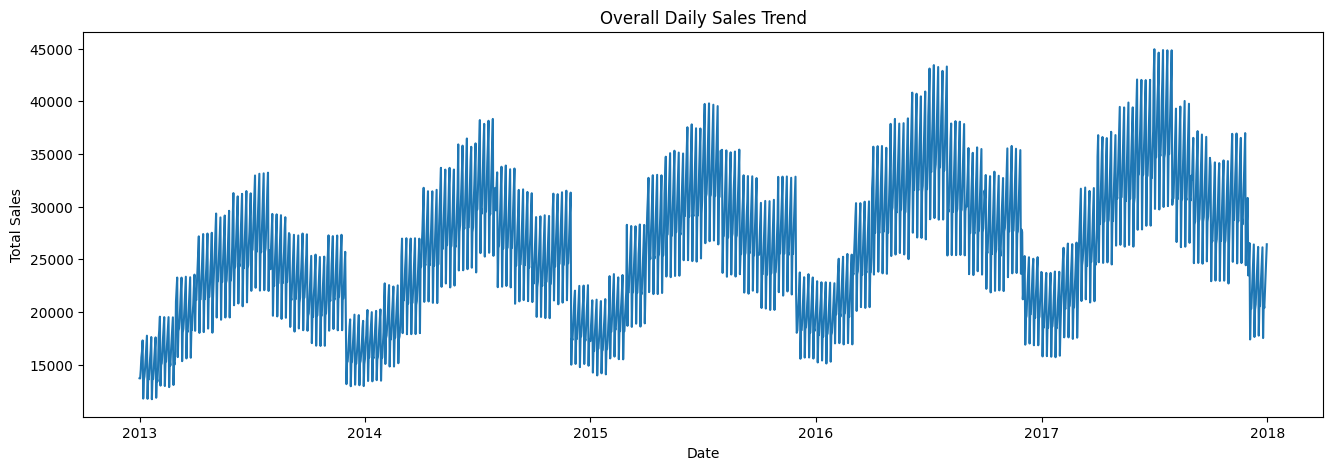

In [53]:
# Group total sales by date
daily_sales = train.groupby("date")["sales"].sum().reset_index()

# Plot overall daily sales trend
plt.figure(figsize=(16, 5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

This overall daily sales trend shows an increasing sales through out 5 years. It also show the difference of sales due to seasonality.

# **Split validation set**

In [54]:
# Use the last 3 months of train.csv as validation set

last_date = train["date"].max()
validation_start = last_date - pd.DateOffset(months=3)

train_part = train[train["date"] <= validation_start]
valid_part = train[train["date"] > validation_start]

print("Train period:", train_part["date"].min(), "to", train_part["date"].max())
print("Validation period:", valid_part["date"].min(), "to", valid_part["date"].max())

Train period: 2013-01-01 00:00:00 to 2017-09-30 00:00:00
Validation period: 2017-10-01 00:00:00 to 2017-12-31 00:00:00


Random split is not suitable because forecasting is use past data to predict future

# **Change column name for Prophet**

In [55]:
def train_and_predict(train_data, future_data):
    # Prophet needs columns named ds and y
    prophet_train = train_data[["date", "sales"]].rename(
        columns={"date": "ds", "sales": "y"}
    )

    # Create Prophet model
    model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )

    # Train model
    model.fit(prophet_train)

    # Prepare future dates
    future = future_data[["date"]].rename(columns={"date": "ds"})

    # Predict
    forecast = model.predict(future)

    # Get prediction
    prediction = forecast["yhat"].values

    # Sales cannot be negative
    prediction = np.maximum(prediction, 0)

    return prediction

# **Train each store-item and predict validation**

In [56]:
all_predictions = []

store_item_list = train_part[["store", "item"]].drop_duplicates()

for index, row in tqdm(store_item_list.iterrows(), total=len(store_item_list)):

    store_id = row["store"]
    item_id = row["item"]

    # Get data for one store-item
    one_train = train_part[
        (train_part["store"] == store_id) &
        (train_part["item"] == item_id)
    ]

    one_valid = valid_part[
        (valid_part["store"] == store_id) &
        (valid_part["item"] == item_id)
    ]

    # Skip if no validation data
    if len(one_valid) == 0:
        continue

    # Train and predict
    pred = train_and_predict(one_train, one_valid)

    # Save result
    result = one_valid.copy()
    result["prediction"] = pred

    all_predictions.append(result)

valid_result = pd.concat(all_predictions)

valid_result.head()

  0%|          | 0/500 [00:00<?, ?it/s]

,date,store,item,sales,prediction
1734,2017-10-01,1,1,21,26.635885
1735,2017-10-02,1,1,12,18.479815
1736,2017-10-03,1,1,18,21.132230
1737,2017-10-04,1,1,15,21.847584
1738,2017-10-05,1,1,20,22.434416


# **Evaluation**

In [57]:
actual = valid_result["sales"]
predicted = valid_result["prediction"]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 6.368657136732602
RMSE: 8.274001198487964
MAPE: 14.201429397131843


**MAE(Mean Absolute Error)**: average of the absolute deviations between predictions and actuals.

**RMSE(Root Mean Square Error)**: measures the standard deviation of prediction errors — giving higher weight to large errors.

**MAPE(Mean Absolute Percentage Error)**: divides each absolute error by the actual value before averaging in percentage.

# **Actual vs Prediction**

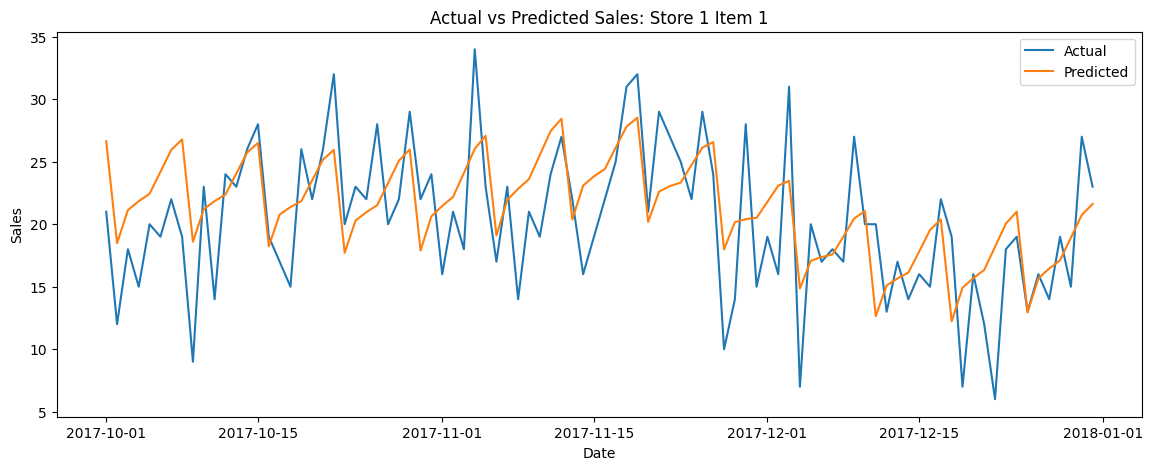

In [58]:
example = valid_result[
    (valid_result["store"] == 1) &
    (valid_result["item"] == 1)
]

plt.figure(figsize=(14, 5))
plt.plot(example["date"], example["sales"], label="Actual")
plt.plot(example["date"], example["prediction"], label="Predicted")
plt.title("Actual vs Predicted Sales: Store 1 Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# **Retrain using full train.csv and predict test.csv**

In [59]:
final_predictions = []

store_item_list = test[["store", "item"]].drop_duplicates()

for index, row in tqdm(store_item_list.iterrows(), total=len(store_item_list)):

    store_id = row["store"]
    item_id = row["item"]

    # Use full train data
    one_train = train[
        (train["store"] == store_id) &
        (train["item"] == item_id)
    ]

    # Test data to predict
    one_test = test[
        (test["store"] == store_id) &
        (test["item"] == item_id)
    ]

    pred = train_and_predict(one_train, one_test)

    result = one_test.copy()
    result["sales"] = pred

    final_predictions.append(result)

test_result = pd.concat(final_predictions)

test_result.head()

  0%|          | 0/500 [00:00<?, ?it/s]

,id,date,store,item,sales
0,0,2018-01-01,1,1,12.983548
1,1,2018-01-02,1,1,15.638641
2,2,2018-01-03,1,1,16.281775
3,3,2018-01-04,1,1,16.942748
4,4,2018-01-05,1,1,18.491937


# **Predict Data**

In [60]:
uploaded = files.upload()

Saving sample_submission.csv to sample_submission (1).csv


In [61]:
submission = test_result[["id", "sales"]].copy()

submission = submission.sort_values("id")

submission.to_csv("submission.csv", index=False)

submission.head()

,id,sales
0,0,12.983548
1,1,15.638641
2,2,16.281775
3,3,16.942748
4,4,18.491937
